In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.chdir('..')
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)


1. ĐỌC VÀ MÔ TẢ DATASET GỐC

In [2]:
file_path = "data/raw/ibtracs_all_list_v04r01_vnm.csv"
df = pd.read_csv(
    file_path,
    skiprows=[1],
    low_memory=False,
    na_values=[' ', '']
)
# Clean thêm các giá trị string missing còn sót
missing_str = ['Missing', 'Not reported']
df = df.replace(missing_str, np.nan)

print("=== THÔNG TIN DATASET GỐC (1870–2026) ===")
print("Số bản ghi/ Số dòng:", df.shape[0])
print("Số biến/ Số cột:", df.shape[1])
file_size = os.path.getsize(file_path) / (1024 * 1024)
print("Kích thước file (MB):", round(file_size, 2))

print("\n=== MÔ TẢ TỪNG BIẾN ===")
for col in df.columns:
    dtype = df[col].dtype
    nunique = df[col].nunique()
    sample = df[col].dropna().iloc[0] if not df[col].dropna().empty else 'N/A'
    print(f"{col:20s}: dtype={dtype}, unique={nunique:,}, mẫu={sample}")


=== THÔNG TIN DATASET GỐC (1870–2026) ===
Số bản ghi/ Số dòng: 227142
Số biến/ Số cột: 10
Kích thước file (MB): 20.52

=== MÔ TẢ TỪNG BIẾN ===
SID                 : dtype=str, unique=4,535, mẫu=1870101S07108
NUMBER              : dtype=int64, unique=142, mẫu=8
BASIN               : dtype=str, unique=4, mẫu=South Indian
SUBBASIN            : dtype=str, unique=4, mẫu=Western Australia
ISO_TIME            : dtype=str, unique=164,734, mẫu=1870-04-10 18:00:00
NATURE              : dtype=str, unique=5, mẫu=Tropical
LAT                 : dtype=float64, unique=907, mẫu=-6.8
LON                 : dtype=float64, unique=1,453, mẫu=107.5
WMO_WIND            : dtype=float64, unique=57, mẫu=20.0
WMO_PRES            : dtype=float64, unique=116, mẫu=1002.0


Nhận xét:
- Các biến BASIN, SUBBASIN, NATURE có kiểu str, số lượng unique thấp, mang tính phân loại nên thuộc nhóm biến nominal.
- SID cũng có kiểu str nhưng đóng vai trò định danh duy nhất (unique count = số cơn bão) - không dùng để phân nhóm mà dùng làm khóa tra cứu.
- Các biến LAT, LON, WMO_WIND, WMO_PRES là các biến numerical liên tục (float64), phù hợp cho phân tích thống kê, phân bố không gian và cường độ bão.
- ISO_TIME là biến thời gian (temporal), phù hợp cho phân tích xu hướng và chuỗi thời gian.


2. CONVERT TỐI THIỂU CHO EDA

In [3]:
numeric_cols = ['WMO_WIND', 'WMO_PRES', 'LAT', 'LON']

df['ISO_TIME'] = pd.to_datetime(df['ISO_TIME'], errors='coerce')

# Kiểm tra NaT sau khi parse ISO_TIME
n_nat = df['ISO_TIME'].isna().sum()
print(f"NaT trong ISO_TIME : {n_nat:,}  ({n_nat / len(df) * 100:.2f}%)")
if n_nat == 0:
    print("ISO_TIME parse hoàn toàn sạch.")
else:
    print("Phát hiện NaT:")
    print(df[df['ISO_TIME'].isna()][['SID', 'ISO_TIME']].head(10))

# Tạo các cột để phục vụ cho EDA -> cuối file drop
df['YEAR'] = df['ISO_TIME'].dt.year
df['MONTH'] = df['ISO_TIME'].dt.month
df['DECADE'] = (df['YEAR'] // 10) * 10


NaT trong ISO_TIME : 0  (0.00%)
ISO_TIME parse hoàn toàn sạch.


Nhận xét: ISO_TIME parse hoàn toàn sạch — không có giá trị NaT.

=> Điều này cho thấy trường thời gian trong dataset IBTrACS có định dạng nhất quán và phù hợp cho phân tích chuỗi thời gian. Cột YEAR, MONTH, DECADE được tạo ra từ ISO_TIME đều đáng tin cậy cho các phân tích thời gian ở các bước tiếp theo.


3. MISSING VALUE

Tổng số ô dữ liệu  : 2,952,846
Tổng số ô missing  : 575,198  (19.48%)
Tỷ lệ dữ liệu sạch : 80.52%

=== CHI TIẾT MISSING THEO CỘT (chỉ cột có missing) ===
          Số missing  Tỷ lệ (%)
WMO_WIND      201680      88.79
SUBBASIN      178290      78.49
WMO_PRES      173331      76.31
NATURE         21897       9.64


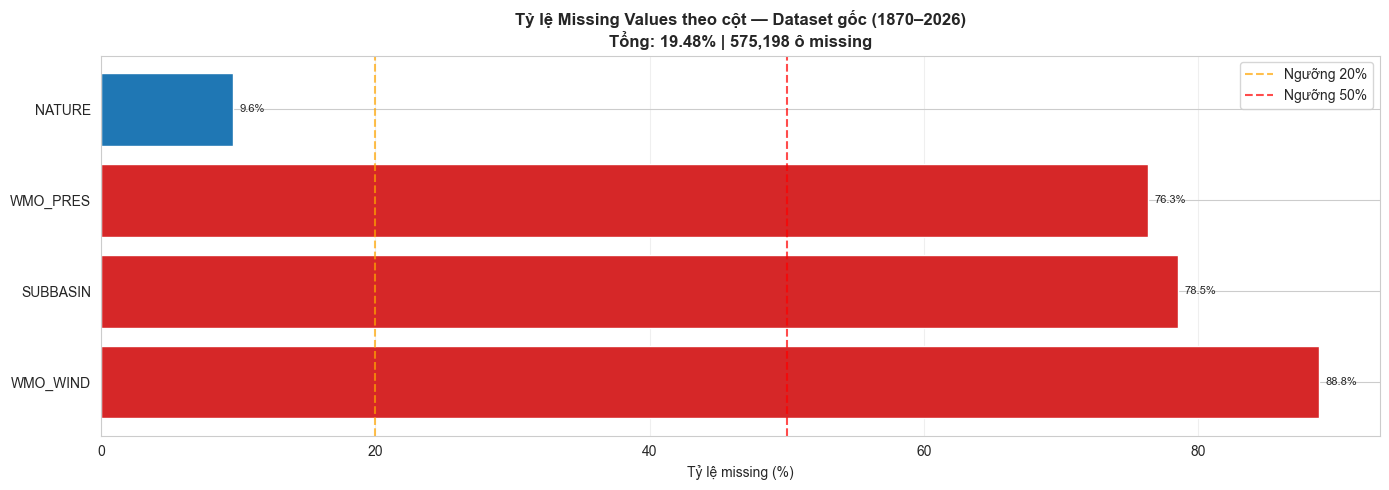


=== TỶ LỆ MISSING (%) THEO THẬP KỶ — TẤT CẢ CỘT CÓ MISSING ===
        WMO_WIND  SUBBASIN  WMO_PRES  NATURE
DECADE                                      
1870       100.0       1.3     100.0    23.0
1880       100.0      45.4     100.0    18.6
1890       100.0      64.7     100.0    19.5
1900       100.0      72.6     100.0    24.8
1910       100.0      78.1     100.0    18.6
1920       100.0      67.0     100.0    13.7
1930       100.0      76.5     100.0    21.3
1940       100.0      71.1     100.0     8.4
1950       100.0      83.4      71.4     0.1
1960       100.0      79.7      67.9     0.0
1970        93.6      82.6      67.8     0.0
1980        77.0      85.4      66.5     0.2
1990        74.9      85.3      63.9    30.4
2000        66.5      85.6      53.1     0.0
2010        65.0      85.8      50.7     0.0
2020        69.8      82.5      57.8    11.0


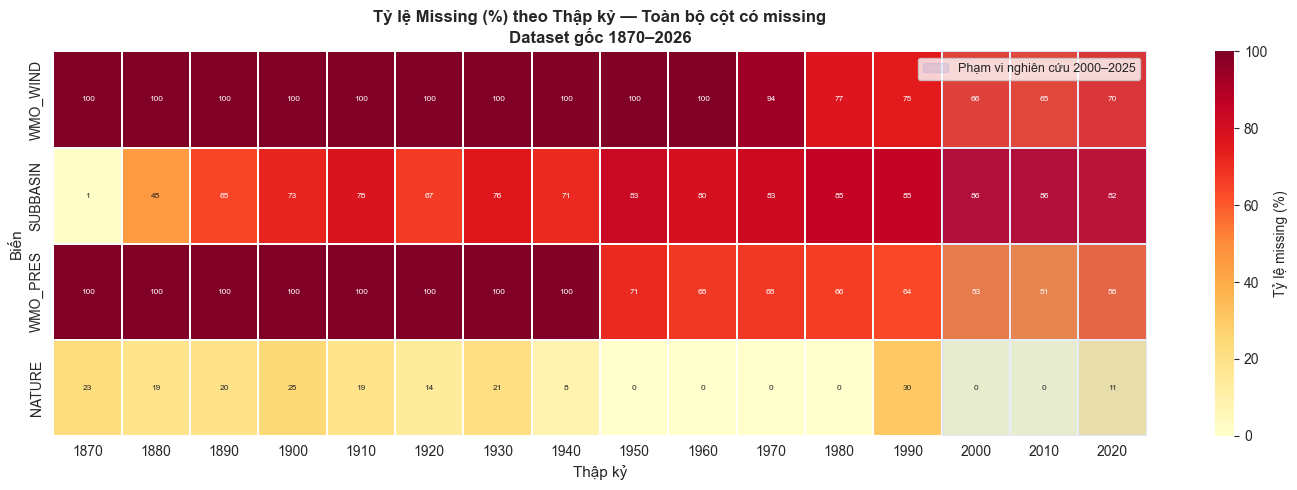

In [4]:
# Tổng quan
total_cells   = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()
missing_pct   = total_missing / total_cells * 100

print(f"Tổng số ô dữ liệu  : {total_cells:,}")
print(f"Tổng số ô missing  : {total_missing:,}  ({missing_pct:.2f}%)")
print(f"Tỷ lệ dữ liệu sạch : {100 - missing_pct:.2f}%\n")

# Chi tiết theo cột (chỉ cột có missing)
missing_detail = pd.DataFrame({
    'Số missing': df.isnull().sum(),
    'Tỷ lệ (%)' : (df.isnull().mean() * 100).round(2)
}).query('`Số missing` > 0').sort_values('Tỷ lệ (%)', ascending=False)

print("=== CHI TIẾT MISSING THEO CỘT (chỉ cột có missing) ===")
print(missing_detail.to_string())

# Bar chart: tất cả cột có missing
fig, ax = plt.subplots(figsize=(14, 5))
colors = [
    '#d62728' if v > 50 else
    '#ff7f0e' if v > 20 else
    '#1f77b4'
    for v in missing_detail['Tỷ lệ (%)']
]
ax.barh(missing_detail.index, missing_detail['Tỷ lệ (%)'], color=colors)
ax.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='Ngưỡng 20%')
ax.axvline(x=50, color='red',    linestyle='--', alpha=0.7, label='Ngưỡng 50%')

# Gắn số % lên mỗi bar
for i, (val, name) in enumerate(zip(missing_detail['Tỷ lệ (%)'], missing_detail.index)):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=8)

ax.set_xlabel('Tỷ lệ missing (%)')
ax.set_title(
    f'Tỷ lệ Missing Values theo cột — Dataset gốc (1870–2026)\n'
    f'Tổng: {missing_pct:.2f}% | {total_missing:,} ô missing',
    fontweight='bold'
)
ax.legend()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Heatmap: tất cả cột có missing × tất cả thập kỷ
cols_with_missing = missing_detail.index.tolist()  # lấy từ missing_detail đã sort

# Tính tỷ lệ missing theo thập kỷ — tránh MultiIndex của pandas >= 2.0
df_decade_missing = (
    df.groupby('DECADE')[cols_with_missing]
    .agg(lambda x: x.isnull().mean() * 100)   # agg thay apply — trả về DataFrame phẳng
    .round(1)
)

print("\n=== TỶ LỆ MISSING (%) THEO THẬP KỶ — TẤT CẢ CỘT CÓ MISSING ===")
print(df_decade_missing.to_string())

# Tự điều chỉnh annot theo kích thước matrix
n_rows, n_cols = df_decade_missing.T.shape
annot_flag = (n_rows * n_cols) <= 120   # tắt annot nếu quá dày
fontsize_annot = max(5, 9 - n_cols // 5)

fig, ax = plt.subplots(figsize=(max(14, n_cols * 0.9), max(5, n_rows * 0.55)))
sns.heatmap(
    df_decade_missing.T,
    annot=annot_flag,
    fmt='.0f' if annot_flag else '',
    annot_kws={'size': fontsize_annot},
    cmap='YlOrRd',
    linewidths=0.3,
    cbar_kws={'label': 'Tỷ lệ missing (%)'},
    ax=ax
)

# Đánh dấu vùng nghiên cứu 2000–2025
decades = list(df_decade_missing.index)
if 2000 in decades:
    start_idx = decades.index(2000)
    ax.axvspan(start_idx, len(decades), alpha=0.12,
               color='royalblue', label='Phạm vi nghiên cứu 2000–2025')
    ax.legend(loc='upper right', fontsize=9)

ax.set_xlabel('Thập kỷ', fontsize=11)
ax.set_ylabel('Biến', fontsize=11)
ax.set_title(
    'Tỷ lệ Missing (%) theo Thập kỷ — Toàn bộ cột có missing\n'
    'Dataset gốc 1870–2026',
    fontweight='bold'
)
plt.tight_layout()
plt.show()

Nhận xét:
- Toàn bộ dataset có tỷ lệ dữ liệu sạch khoảng 80.52%, tuy nhiên phân bố missing không đồng đều giữa các thuộc tính.
- Các biến WMO_WIND (88.79%) và WMO_PRES (76.31%) có tỷ lệ thiếu rất cao, đặc biệt ở giai đoạn trước năm 1950 gần như thiếu hoàn toàn do hạn chế về công nghệ quan trắc lịch sử.
- Biến SUBBASIN cũng có tỷ lệ missing lớn (78.49%) và duy trì cao ở hầu hết các thập kỷ, cho thấy thuộc tính này không ổn định cho phân tích dài hạn.
- Biến NATURE có tỷ lệ missing thấp hơn (9.64%) và nhìn chung khá đầy đủ từ sau năm 1950.
- Trong phạm vi nghiên cứu 2000–2025, tỷ lệ missing của WMO_WIND và WMO_PRES đã giảm đáng kể nhưng vẫn còn ở mức cao, trong khi SUBBASIN tiếp tục thiếu trên 80%.
Kết quả cho thấy chất lượng dữ liệu được cải thiện theo thời gian, đặc biệt ở các biến khí tượng chính sau năm 2000.

4. PHÂN PHỐI CÁC BIẾN SỐ (HISTOGRAM)


=== THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ ===
       WMO_WIND  WMO_PRES        LAT        LON
count  25462.00  53811.00  227142.00  227142.00
mean      54.85    985.48      18.75     118.46
std       21.92     21.82       9.08      21.57
min        3.00    870.00     -37.40      42.20
25%       35.00    976.00      13.40     108.60
50%       50.00    994.00      18.20     122.10
75%       70.00   1000.00      22.80     131.60
max      140.00   1018.00      69.00     211.70

=== SKEWNESS ===
WMO_WIND    0.606
WMO_PRES   -1.546
LAT         0.433
LON        -0.234
dtype: float64


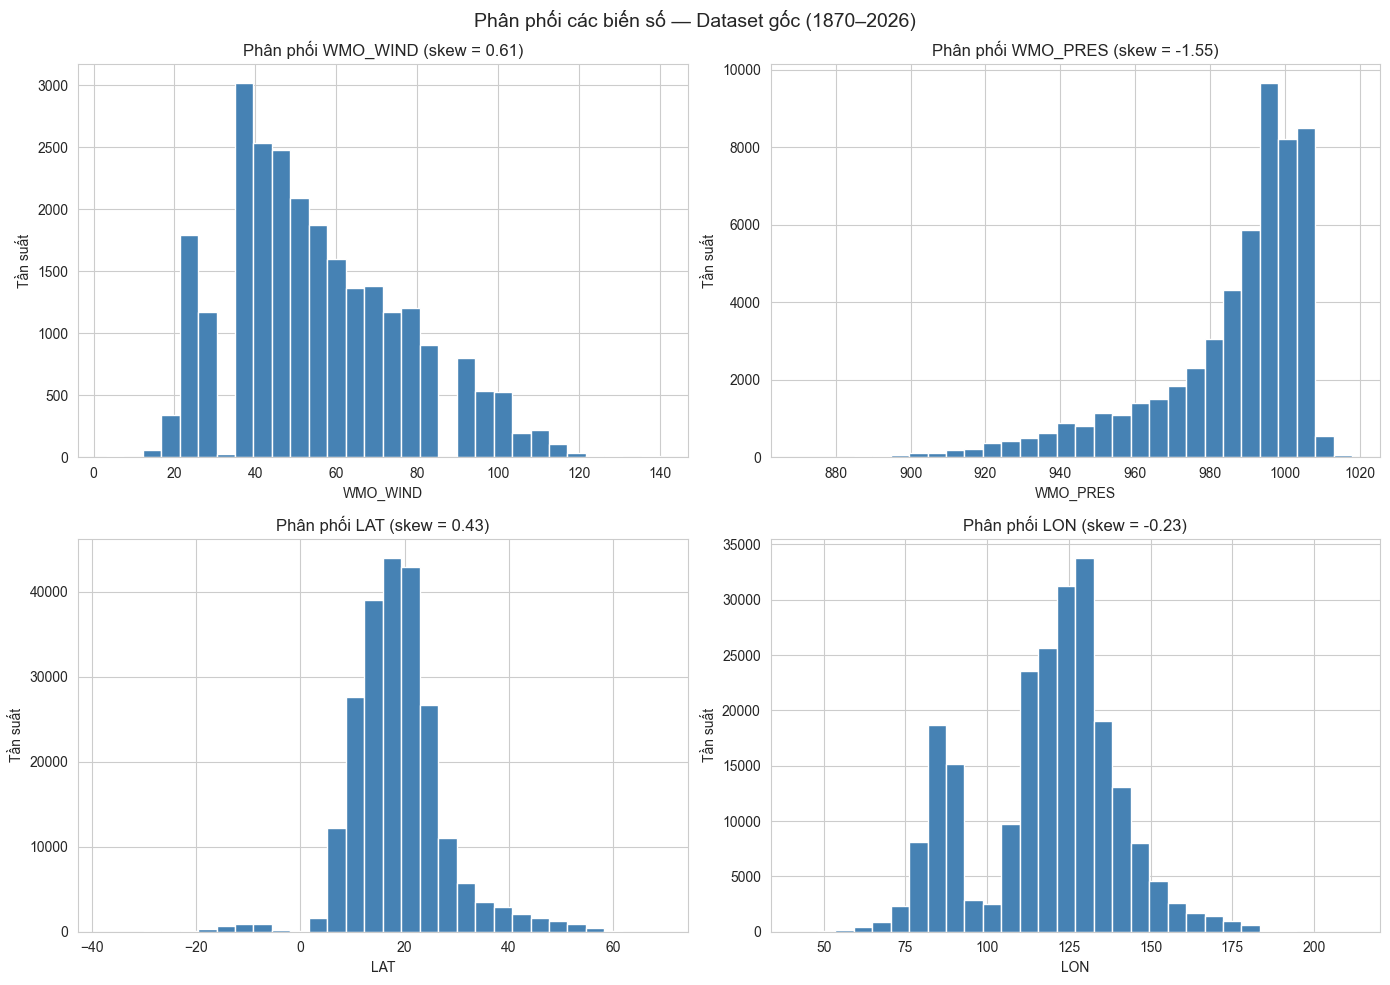

In [5]:
print("\n=== THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ ===")
print(df[numeric_cols].describe().round(2))

print("\n=== SKEWNESS ===")
print(df[numeric_cols].skew().round(3))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), numeric_cols):
    df[col].dropna().hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Phân phối {col} (skew = {df[col].skew():.2f})')
    ax.set_xlabel(col)
    ax.set_ylabel('Tần suất')
plt.suptitle('Phân phối các biến số — Dataset gốc (1870–2026)', fontsize=14)
plt.tight_layout()
plt.show()

Nhận xét:
- WMO_WIND lệch phải → phần lớn bão có cường độ trung bình–thấp, ít bão rất mạnh.
- WMO_PRES lệch trái rõ → đa số áp suất cao, chỉ một số ít bão mạnh (áp suất thấp).
- LAT tập trung quanh 10–25° → bão chủ yếu ở vùng nhiệt đới Bắc bán cầu.
- LON tập trung ~100–140° → phù hợp khu vực Tây Thái Bình Dương.

→ Phân bố dữ liệu phù hợp với đặc điểm khí hậu khu vực và phạm vi nghiên cứu, đồng thời cho thấy cường độ bão không phân bố đồng đều.

5. Mối quan hệ Wind–Pressure (Kiểm tra chất lượng dữ liệu)


Tương quan Pearson  WMO_WIND vs WMO_PRES : -0.9472
Tương quan Spearman WMO_WIND vs WMO_PRES : -0.9423


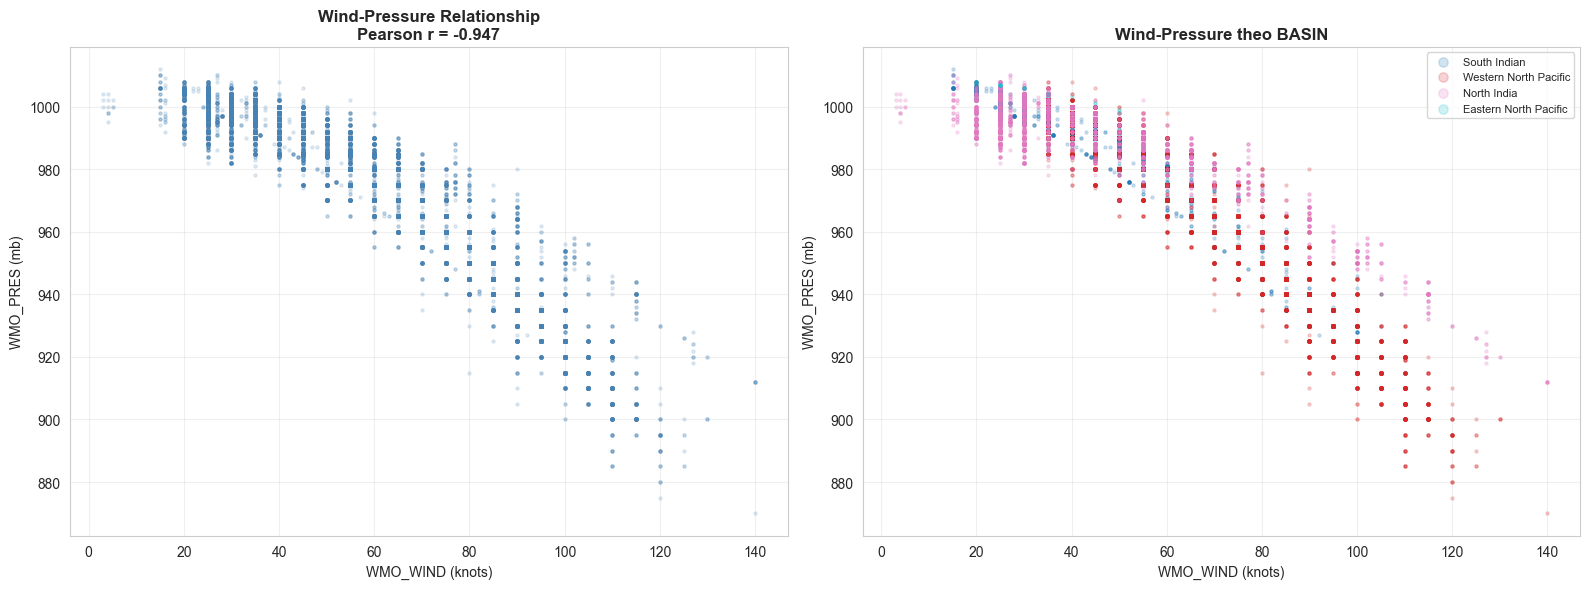

In [6]:
df_wp = df[['WMO_WIND', 'WMO_PRES', 'BASIN']].dropna()

corr_pearson  = df_wp['WMO_WIND'].corr(df_wp['WMO_PRES'])
corr_spearman = df_wp['WMO_WIND'].corr(df_wp['WMO_PRES'], method='spearman')
print(f"Tương quan Pearson  WMO_WIND vs WMO_PRES : {corr_pearson:.4f}")
print(f"Tương quan Spearman WMO_WIND vs WMO_PRES : {corr_spearman:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df_wp['WMO_WIND'], df_wp['WMO_PRES'],
                alpha=0.15, s=5, color='steelblue')
axes[0].set_xlabel('WMO_WIND (knots)')
axes[0].set_ylabel('WMO_PRES (mb)')
axes[0].set_title(f'Wind-Pressure Relationship\nPearson r = {corr_pearson:.3f}', fontweight='bold')
axes[0].grid(True, alpha=0.3)

basins = df_wp['BASIN'].unique()
cmap   = plt.cm.get_cmap('tab10', len(basins))
for i, basin in enumerate(basins):
    mask = df_wp['BASIN'] == basin
    axes[1].scatter(df_wp.loc[mask, 'WMO_WIND'], df_wp.loc[mask, 'WMO_PRES'],
                    alpha=0.2, s=5, color=cmap(i), label=basin)
axes[1].set_xlabel('WMO_WIND (knots)')
axes[1].set_ylabel('WMO_PRES (mb)')
axes[1].set_title('Wind-Pressure theo BASIN', fontweight='bold')
axes[1].legend(markerscale=3, fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Nhận xét:
- Tương quan Pearson đạt **r = -0.9472** (Spearman ρ = -0.9423) cho thấy mối quan hệ nghịch rất mạnh giữa tốc độ gió và áp suất trung tâm, phù hợp với đặc trưng vật lý của xoáy thuận nhiệt đới.
- Biểu đồ cho thấy áp suất trung tâm có xu hướng giảm khi tốc độ gió tăng.
- Các dải thẳng đứng là đặc trưng của best-track data do wind speed thường được làm tròn hoặc ước lượng theo bậc.
- Khi phân theo BASIN, xu hướng wind–pressure vẫn duy trì nhất quán giữa các khu vực đại dương, cho thấy đặc điểm vật lý tương đồng của tropical cyclone trên phạm vi toàn cầu.
- Một số khác biệt nhỏ về mật độ và phạm vi phân bố giữa các BASIN phản ánh sự khác nhau về tần suất và cường độ bão của từng khu vực khí hậu.

6. PHÂN BỐ BASIN & NATURE

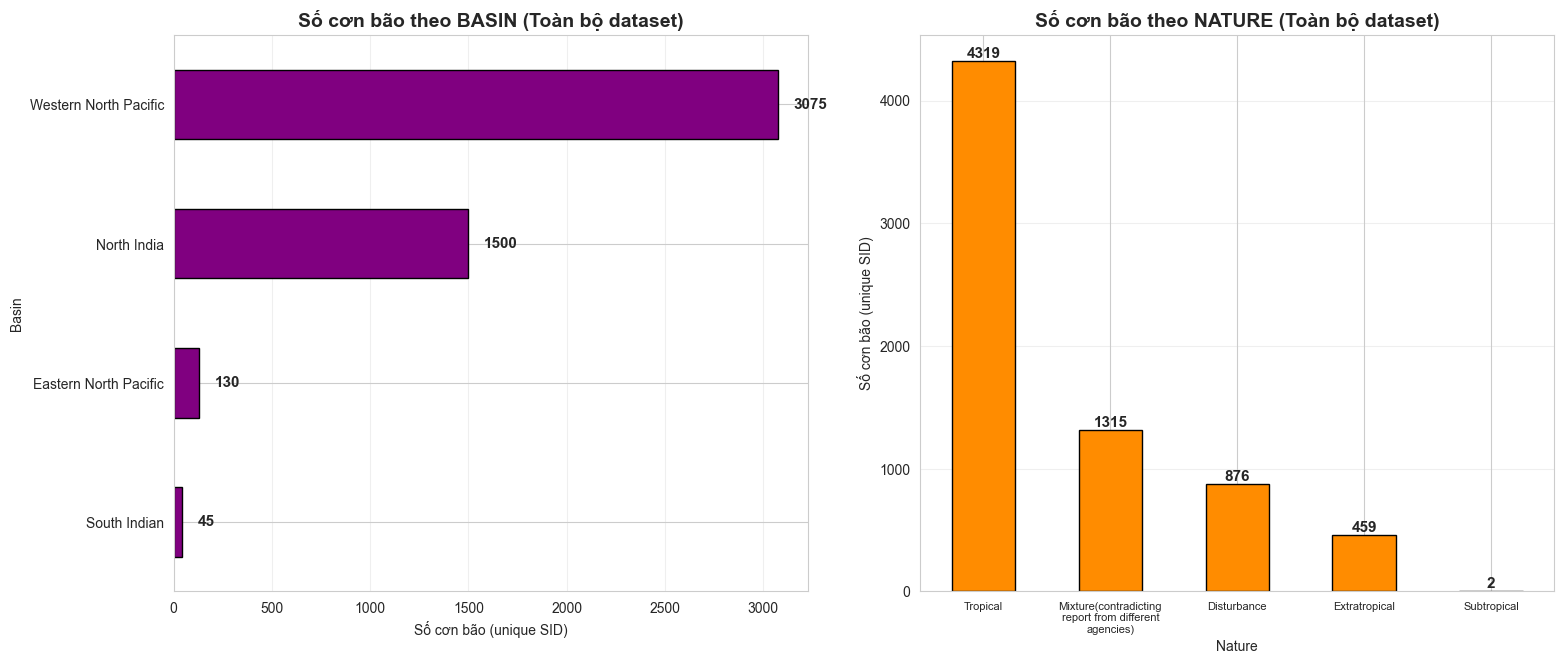

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Số cơn bão theo BASIN
basin_counts = df.groupby('BASIN')['SID'].nunique().sort_values(ascending=True)

basin_counts.plot(kind='barh', ax=axes[0], color='purple', edgecolor='black')
axes[0].set_title('Số cơn bão theo BASIN (Toàn bộ dataset)',
                  fontweight='bold', fontsize=14)
axes[0].set_xlabel('Số cơn bão (unique SID)')
axes[0].set_ylabel('Basin')
axes[0].grid(axis='x', alpha=0.3)

for i, v in enumerate(basin_counts):
    axes[0].text(v + 80, i, str(v), va='center', fontsize=11, fontweight='bold')

# Số cơn bão theo NATURE
nature_counts = df.groupby('NATURE')['SID'].nunique().sort_values(ascending=False)

nature_counts.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Số cơn bão theo NATURE (Toàn bộ dataset)',
                  fontweight='bold', fontsize=14)
axes[1].set_xlabel('Nature')
axes[1].set_ylabel('Số cơn bão (unique SID)')
axes[1].grid(axis='y', alpha=0.3)

import textwrap

# Wrap label dài thành nhiều dòng
wrapped_labels = [textwrap.fill(label, width=21) for label in nature_counts.index]
axes[1].set_xticks(range(len(nature_counts)))
axes[1].set_xticklabels(wrapped_labels, rotation=0, ha='center', fontsize=8)

for i, v in enumerate(nature_counts):
    axes[1].text(i, v + 30, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout(pad=2.0)
plt.show()

Nhận xét:
- Theo BASIN: Western North Pacific chiếm ưu thế tuyệt đối với 3.075 cơn bão (chiếm khoảng 68% tổng số storm), phù hợp với khu vực nghiên cứu chính ảnh hưởng đến Việt Nam. North India đứng thứ hai với 1.500 cơn, trong khi Eastern North Pacific và South Indian chiếm tỷ lệ rất nhỏ.
- Theo NATURE: Phần lớn các cơn bão được phân loại là Tropical (4.319 cơn).  Các loại khác gồm Mixture (1,315), Disturbance (876), Extratropical (459) và Subtropical (2). Giá trị Mixture phản ánh các trường hợp các agency báo cáo mâu thuẫn nhau về loại hình bão

Kết luận: Dữ liệu tập trung mạnh vào Western North Pacific và loại Tropical, rất phù hợp cho các phân tích sâu về bão ảnh hưởng đến Việt Nam trong giai đoạn nghiên cứu.

7. Phân bố theo thời gian

Phạm vi dataset: 1870–T2/2026
Lưu ý:2026 chỉ có dữ liệu đến tháng 2 (06/02/2026) — chưa đầy năm


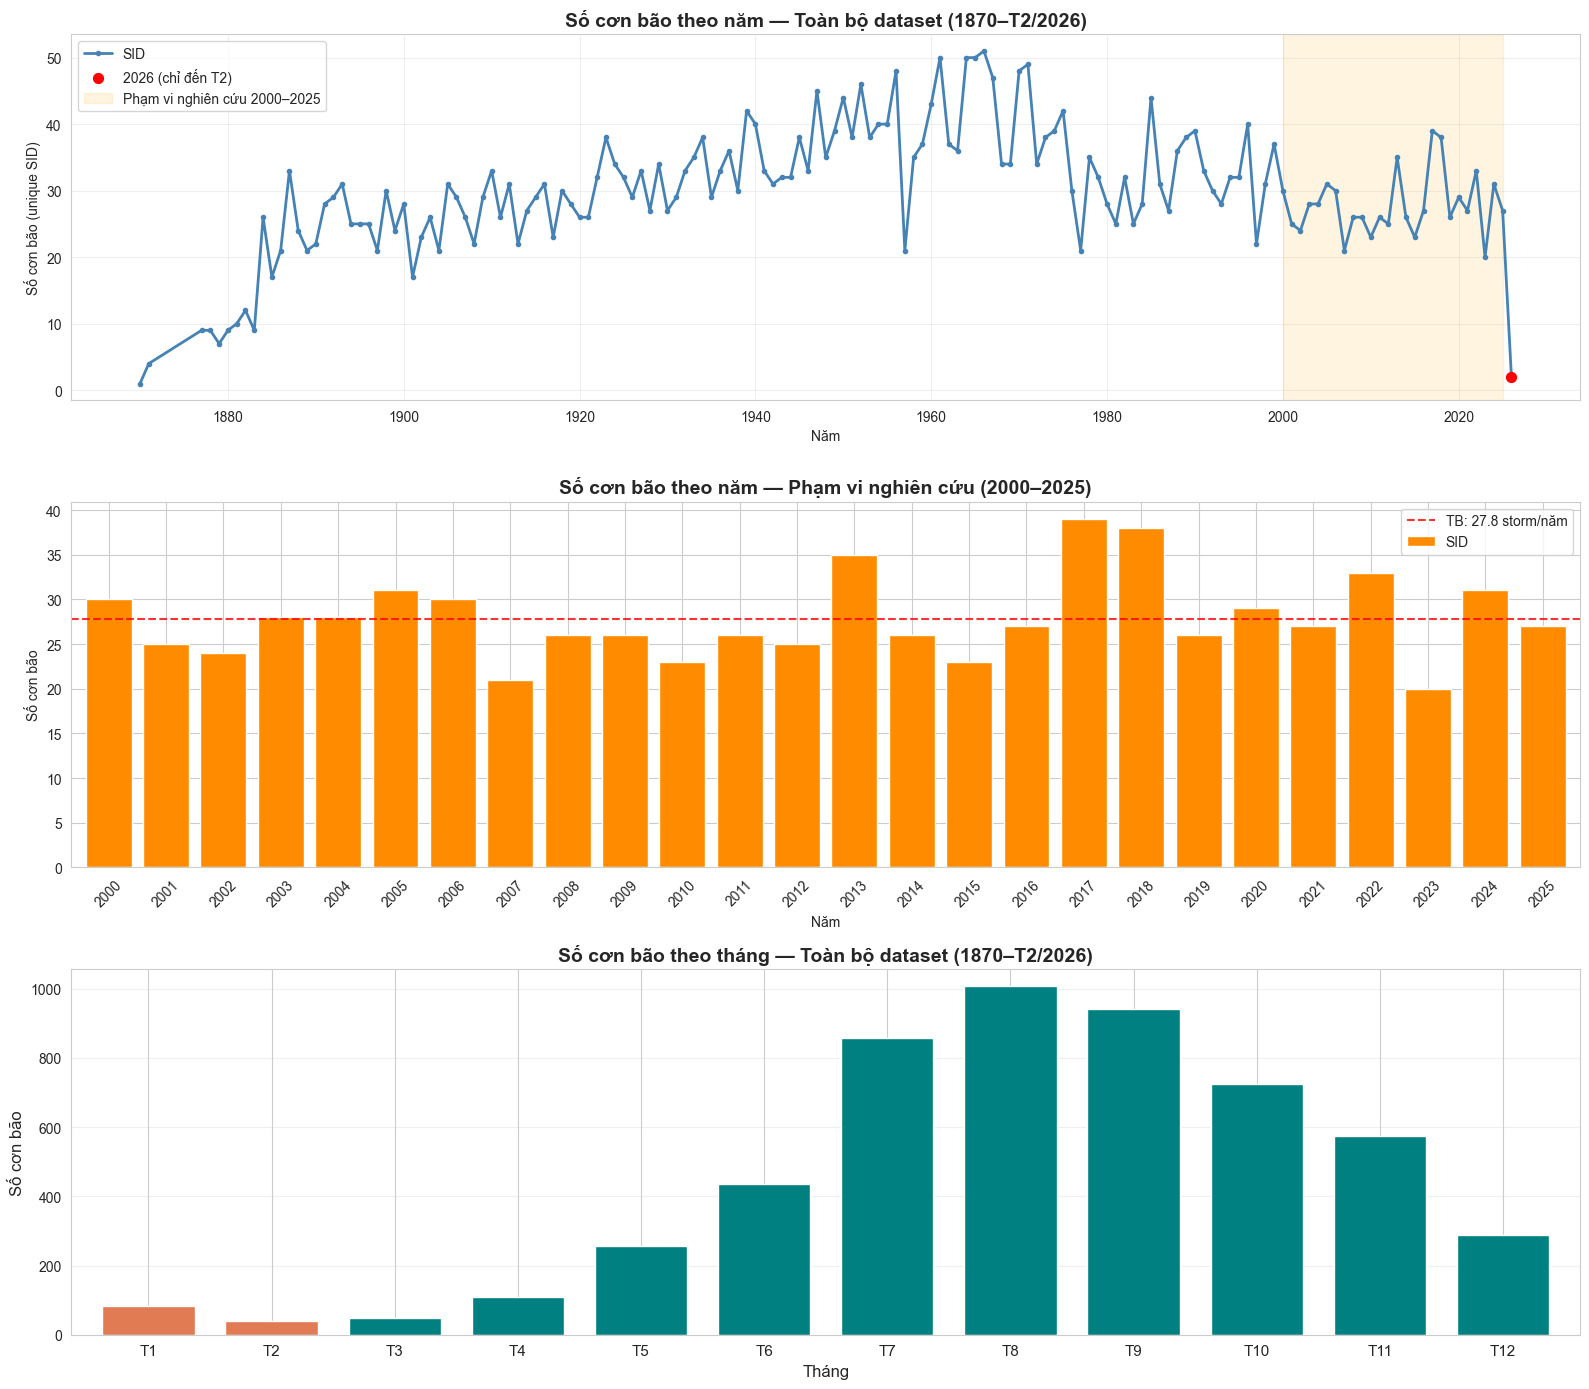

Unique SID trong 2000–2025: 719


In [8]:
# Tự động detect năm/tháng cuối
year_min   = int(df['YEAR'].min())
year_max   = int(df['YEAR'].max())
last_month = int(df[df['YEAR'] == year_max]['MONTH'].max())
last_date  = df['ISO_TIME'].max().strftime('%d/%m/%Y')
is_partial = last_month < 12

range_label = f'{year_min}–T{last_month}/{year_max}' if is_partial else f'{year_min}–{year_max}'

print(f'Phạm vi dataset: {range_label}')
if is_partial:
    print(f'Lưu ý:{year_max} chỉ có dữ liệu đến tháng {last_month} ({last_date}) — chưa đầy năm')

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Toàn bộ lịch sử
year_counts_full = df.groupby('YEAR')['SID'].nunique()
year_counts_full.plot(kind='line', ax=axes[0], color='steelblue',
                     marker='o', markersize=3, linewidth=2)

if is_partial:
    axes[0].scatter([year_max], [year_counts_full[year_max]],
                   color='red', s=50, zorder=5,
                   label=f'{year_max} (chỉ đến T{last_month})')

axes[0].axvspan(2000, 2025, alpha=0.12, color='orange', label='Phạm vi nghiên cứu 2000–2025')
axes[0].set_title(f'Số cơn bão theo năm — Toàn bộ dataset ({range_label})', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Năm')
axes[0].set_ylabel('Số cơn bão (unique SID)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Zoom 2000–2025
year_counts_zoom = df[(df['YEAR'] >= 2000) & (df['YEAR'] <= 2025)].groupby('YEAR')['SID'].nunique()
year_counts_zoom.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white', width=0.8)
axes[1].axhline(y=year_counts_zoom.mean(), color='red', linestyle='--', alpha=0.8,
                label=f'TB: {year_counts_zoom.mean():.1f} storm/năm')
axes[1].set_title('Số cơn bão theo năm — Phạm vi nghiên cứu (2000–2025)', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Năm')
axes[1].set_ylabel('Số cơn bão')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=10)

# Theo tháng (toàn bộ)
month_counts = df.groupby('MONTH')['SID'].nunique().reindex(range(1,13), fill_value=0)
bars = month_counts.plot(kind='bar', ax=axes[2], color='teal', edgecolor='white', width=0.75)

if is_partial:
    for i in range(last_month):
        bars.patches[i].set_facecolor('#e07b54')

axes[2].set_title(f'Số cơn bão theo tháng — Toàn bộ dataset ({range_label})',
                  fontweight='bold', fontsize=14)
axes[2].set_xlabel('Tháng', fontsize=12)
axes[2].set_ylabel('Số cơn bão', fontsize=12)
axes[2].set_xticks(range(12))
axes[2].set_xticklabels(['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12'],
                        rotation=0, fontsize=11)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print(f'Unique SID trong 2000–2025: {df[(df["YEAR"]>=2000)&(df["YEAR"]<=2025)]["SID"].nunique():,}')

Nhận xét:
- Toàn bộ dataset bao gồm 4.535 cơn bão từ năm 1870 đến tháng 2/2026.
- Theo năm: Số lượng cơn bão tăng rõ rệt từ đầu thế kỷ 20 và ổn định ở mức 25–50 cơn/năm kể từ những năm 1940. Giai đoạn nghiên cứu 2000–2025 có trung bình 27.8 cơn bão mỗi năm, với biến động đáng kể giữa các năm (cao nhất vào các năm 2016–2017). Năm 2026 hiện chỉ ghi nhận rất ít dữ liệu (đến tháng 2).
- Theo tháng: Các cơn bão tập trung mạnh vào mùa bão từ tháng 7 đến tháng 10, trong đó tháng 8 và 9 là cao điểm rõ rệt. Điều này hoàn toàn phù hợp với đặc trưng mùa bão Tây Bắc Thái Bình Dương và Biển Đông.
- Giai đoạn nghiên cứu: Trong khoảng thời gian 2000–2025 có tổng cộng 719 cơn bão duy nhất, chiếm tỷ lệ hợp lý để tiến hành các phân tích sâu hơn.

08. Phân bố không gian

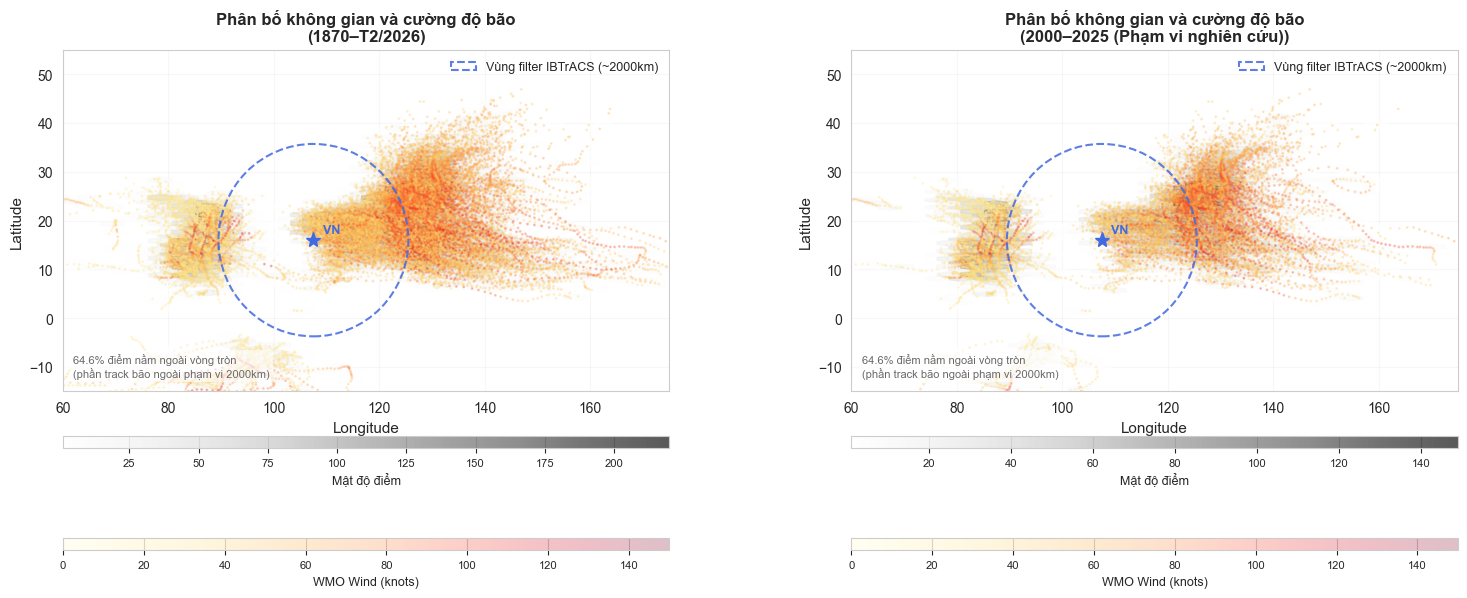

In [9]:
from matplotlib.patches import Ellipse
from mpl_toolkits.axes_grid1 import make_axes_locatable

df['LON_plot'] = np.where(df['LON'] > 180, df['LON'] - 360, df['LON'])

XLIM   = (60, 175)
YLIM   = (-15, 55)
VN_LON = 107.5
VN_LAT = 16.0

fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))
fig.subplots_adjust(wspace=0.3)

for ax, data, period in zip(axes,
    [df, df[(df['YEAR'] >= 2000) & (df['YEAR'] <= 2025)]],
    ['1870–T2/2026', '2000–2025 (Phạm vi nghiên cứu)']):

    df_sp = data[['LAT', 'LON_plot', 'WMO_WIND']].dropna()

    hb = ax.hexbin(df_sp['LON_plot'], df_sp['LAT'],
                   gridsize=80, cmap='Greys', mincnt=1, alpha=0.65)
    sc = ax.scatter(df_sp['LON_plot'], df_sp['LAT'],
                    c=df_sp['WMO_WIND'], cmap='YlOrRd',
                    s=1.2, alpha=0.25, vmin=0, vmax=150)

    ax.set_xlim(XLIM)
    ax.set_ylim(YLIM)
    ax.set_xlabel('Longitude', fontsize=11)
    ax.set_ylabel('Latitude', fontsize=11)
    ax.set_title(f'Phân bố không gian và cường độ bão\n({period})',
                 fontweight='bold', fontsize=12)
    ax.grid(alpha=0.15)

    # Colorbar nằm dưới subplot
    divider = make_axes_locatable(ax)
    cax1 = divider.append_axes('bottom', size='3.5%', pad=0.45)
    cax2 = divider.append_axes('bottom', size='3.5%', pad=0.9)
    cb1 = fig.colorbar(hb, cax=cax1, orientation='horizontal')
    cb2 = fig.colorbar(sc, cax=cax2, orientation='horizontal')
    cb1.set_label('Mật độ điểm', fontsize=9)
    cb2.set_label('WMO Wind (knots)', fontsize=9)
    cb1.ax.tick_params(labelsize=8)
    cb2.ax.tick_params(labelsize=8)

    # Ellipse bù aspect ratio để nhìn tròn trên plot
    # r=18° ≈ 2000km, xấp xỉ trực quan — Circle trên lon-lat không phải tròn địa lý
    x_range = XLIM[1] - XLIM[0]  # 115
    y_range = YLIM[1] - YLIM[0]  # 70
    ax_w, ax_h = 7.8, 5.2        # inch ước tính subplot
    scale = (y_range / x_range) * (ax_w / ax_h)
    r = 18
    ellipse = Ellipse(
        (VN_LON, VN_LAT),
        width=r * 2, height=r * 2 / scale,
        fill=False, edgecolor='royalblue',
        linewidth=1.5, linestyle='--', alpha=0.85,
        label='Vùng filter IBTrACS (~2000km)'
    )
    ax.add_patch(ellipse)
    ax.plot(VN_LON, VN_LAT, marker='*', color='royalblue', markersize=11, zorder=5)
    ax.text(VN_LON + 1.8, VN_LAT + 1.5, 'VN',
            color='royalblue', fontsize=9, fontweight='bold')

    ax.text(62, -12,
            '64.6% điểm nằm ngoài vòng tròn\n(phần track bão ngoài phạm vi 2000km)',
            fontsize=8, color='dimgray',
            bbox=dict(facecolor='white', alpha=0.65, pad=2, edgecolor='none'))

    ax.legend(loc='upper right', fontsize=9, frameon=False)

plt.show()

df = df.drop(columns=['LON_plot'], errors='ignore')

Nhận xét:
- Phân bố không gian và cường độ bão giữa hai giai đoạn (toàn bộ lịch sử và 2000–2025) có sự tương đồng cao, cho thấy dữ liệu giai đoạn nghiên cứu đại diện tốt cho xu hướng dài hạn của các cơn bão trong phạm vi khoảng 2000km quanh Việt Nam.

- Quỹ đạo bão tập trung chủ yếu tại Tây Bắc Thái Bình Dương và Biển Đông, với mật độ cao nhất tại khu vực phía đông Philippines và phía Đông Việt Nam - những vùng thường xuất hiện và phát triển mạnh của bão ảnh hưởng đến Việt Nam.

- Bão mạnh (WMO Wind cao) thường hình thành hoặc đạt cường độ lớn ở phía đông Philippines và có xu hướng suy giảm dần khi di chuyển sâu vào Biển Đông, tiến gần bờ biển Việt Nam.

- Một số quỹ đạo bão lệch lên phía Bắc/ Đông Bắc, phản ánh hiện tượng **recurvature** điển hình sau khi rời khỏi vùng nhiệt đới.

- Mật độ hexbin ở giai đoạn 2000–2025 thấp hơn chủ yếu do khoảng thời gian quan sát ngắn hơn, không phản ánh sự thay đổi đáng kể về đặc trưng phân bố địa lý của bão trong khu vực nghiên cứu.

9. Kiểm tra outlier

Flag toàn bộ các điểm nghi ngờ trên dữ liệu thô để đánh giá outlier trước khi lọc năm và xử lý.

Có 2 loại outlier là Intrinsic (Dữ liệu tự nhiên xuất hiện Outlier) và Extrinsic (Lỗi dữ liệu)

9.1 Outlier Intrinsic

a. Intrinsic: WMO_WIND cao / WMO_PRES thấp

Nguyên lý: Giá trị cực đoan của WMO_WIND và WMO_PRES (WMO_WIND quá cao, WMO_PRES thấp) có thật, nó là sự thật về mặt vật lý.

In [10]:
# INTRINSIC: WMO_WIND CAO / WMO_PRES THẤP

# Ngưỡng xác định outlier WMO_WIND cao / WMO_PRES thấp
WIND_EXTREME = 150   # knots
PRES_EXTREME = 900   # mb

n_wind = int((df['WMO_WIND'] > WIND_EXTREME).sum())
n_pres = int((df['WMO_PRES'] < PRES_EXTREME).sum())
n_storm_wind = df[df['WMO_WIND'] > WIND_EXTREME]['SID'].nunique()
n_storm_pres = df[df['WMO_PRES'] < PRES_EXTREME]['SID'].nunique()

print('INTRINSIC: WMO_WIND CAO / WMO_PRES THẤP')
print()
print(f'Số bão cường độ gió cực mạnh (> {WIND_EXTREME} kt) : {n_wind:,} obs | {n_storm_wind} cơn bão')
print(f'Số bão có áp suất cực thấp   (< {PRES_EXTREME} mb) : {n_pres:,} obs | {n_storm_pres} cơn bão')
print('→ Đây là Intrinsic Outlier - có cơ sở vật lý (các siêu bão lịch sử).')

INTRINSIC: WMO_WIND CAO / WMO_PRES THẤP

Số bão cường độ gió cực mạnh (> 150 kt) : 0 obs | 0 cơn bão
Số bão có áp suất cực thấp   (< 900 mb) : 98 obs | 27 cơn bão
→ Đây là Intrinsic Outlier - có cơ sở vật lý (các siêu bão lịch sử).


b. Intrinsic: Rapid Intensification / Weakening (RI/RW) - Bão mạnh lên rất nhanh/Bão yếu đi rất nhanh

**Định nghĩa theo chuẩn NOAA/NHC**: Một cơn gió được coi là một RI nếu tốc độ gió cực đại tăng ít nhất 35 knots trong vòng 24 giờ

Nếu:
- ΔWIND_24h ≥ +35 knots → Rapid Intensification (RI)
- ΔWIND_24h ≤ −35 knots → Rapid Weakening (RW)

RI/RW hiện tượng có thật (Ví dụ cơn bão Haiyan tăng 85 knots trong 24h), nhưng:
- Nếu ΔWIND cực lớn tại 1 điểm duy nhất rồi lại quay về bình thường ngay sau đó → đây là spike cô lập, là 1 Extrinsic
- Nếu ΔWIND lớn **liên tục nhiều điểm** → RI/RW thực sự, là Intrinsic

In [11]:
# INTRINSIC/EXTRINSIC: RI / RW / SPIKE CÔ LẬP

# Ngưỡng xác định outlier RI / RW / Spike cô lập
RI_THRESHOLD = 35 # knots / 24h
SPIKE_3H = 30     # knots / 3h

# Tính mức thay đổi cường độ bão (cách nhau 3h)
df['dWIND_3h'] = df.groupby('SID')['WMO_WIND'].diff()
# Tính thay đổi trong 24h (cách nhau 8 bước 3h = 24h)
df['dWIND_24h'] = df.groupby('SID')['WMO_WIND'].diff(8)
# Kiểm tra có đúng đủ 24h không, phòng trường hợp có gap dữ liệu
df['dt_8step'] = df.groupby('SID')['ISO_TIME'].diff(8).dt.total_seconds() / 3600
# Lấy giá trị dWIND_3h của bước tiếp theo
df['dWIND_3h_next'] = df.groupby('SID')['dWIND_3h'].shift(-1)

n_ri = int(((df['dWIND_24h'] >=  RI_THRESHOLD) & (df['dt_8step'] == 24)).sum())
n_rw = int(((df['dWIND_24h'] <= -RI_THRESHOLD) & (df['dt_8step'] == 24)).sum())
n_spike = int(((df['dWIND_3h'].abs() >= SPIKE_3H) &
               (df['dWIND_3h'] * df['dWIND_3h_next'] < 0)).sum())
n_storm_ri = df[(df['dWIND_24h'] >=  RI_THRESHOLD) & (df['dt_8step'] == 24)]['SID'].nunique()
n_storm_rw = df[(df['dWIND_24h'] <= -RI_THRESHOLD) & (df['dt_8step'] == 24)]['SID'].nunique()
n_storm_spike = df[(df['dWIND_3h'].abs() >= SPIKE_3H) & (df['dWIND_3h'] * df['dWIND_3h_next'] < 0)]['SID'].nunique()

print('INTRINSIC/EXTRINSIC: RI / RW / SPIKE CÔ LẬP')
print()
print(f'Rapid Intensification - bão tăng cường độ nhanh (ΔWIND_24h ≥ +{RI_THRESHOLD} kt) : {n_ri:,} obs | {n_storm_ri} cơn bão')
print(f'Rapid Weakening       - bão suy yếu nhanh       (ΔWIND_24h ≤ -{RI_THRESHOLD} kt) : {n_rw:,} obs | {n_storm_rw} cơn bão')
print(f'→ RI/RW là hiện tượng vật lý có thật (Intrinsic).')
print()
print(f'Spike cô lập - thay đổi đột ngột rồi đảo chiều ngay (|ΔWIND_3h| ≥ {SPIKE_3H} kt) : {n_spike:,} obs | {n_storm_spike} cơn bão')
print(f'→ Lỗi dữ liệu (Extrinsic).')

INTRINSIC/EXTRINSIC: RI / RW / SPIKE CÔ LẬP

Rapid Intensification - bão tăng cường độ nhanh (ΔWIND_24h ≥ +35 kt) : 385 obs | 140 cơn bão
Rapid Weakening       - bão suy yếu nhanh       (ΔWIND_24h ≤ -35 kt) : 406 obs | 182 cơn bão
→ RI/RW là hiện tượng vật lý có thật (Intrinsic).

Spike cô lập - thay đổi đột ngột rồi đảo chiều ngay (|ΔWIND_3h| ≥ 30 kt) : 0 obs | 0 cơn bão
→ Lỗi dữ liệu (Extrinsic).


9.2 Outlie Extrinsic

a. Extrinsic: Wind–Pressure Consistency

**Nguyên lý vật lý**: Gió mạnh hơn, Áp suất trung tâm thấp hơn (nghịch chiều). Hay có thể giải thích là WIND và PRESSURE thường biến đổi ngược chiều nhau, và nếu gió và áp suất lại tăng/giảm cùng nhau thì đáng nghi.

- Nếu dWIND và dPRES nhỏ, biên độ nhỏ thì tính là vi phạm nhẹ, là hiện tượng tự nhiên khi bão hình thành hoặc tan rã (Intrinsic)

- Nếu dWIND và dPRES lớn, biên độ lớn thì tính là vi phạm nặng, lúc này là lỗi dữ liệu (Extrinsic).

**Flag bất thường**: Khi dWIND và dPRES **cùng chiều** (cả hai cùng tăng hoặc cùng giảm) -> vi phạm vật lý.

In [12]:
# INTRINSIC/EXTRINSIC: KIỂM TRA WIND VÀ PRESSURE có hợp lệ hay không

# Ngưỡng xác định outlier Wind–Pressure Consistency
# Đặt ngưỡng để kiểm tra các noise quá nhỏ, không có ý nghĩa vật lý
WIND_NOISE = 2  # knots — ngưỡng noise tối thiểu
PRES_NOISE = 1  # mb    — ngưỡng noise tối thiểu
# Lọc các vi phạm nặng
HEAVY_VIOLATION = 10  # knots — vi phạm nặng

# Lấy dòng có đủ dữ liệu dWIND_3h và dPRES_3h
df['dPRES_3h'] = df.groupby('SID')['WMO_PRES'].diff()
mask_wp = df['dWIND_3h'].notna() & df['dPRES_3h'].notna()
df_wp   = df[mask_wp].copy()

# Kiểm tra tính nhất quán giữa dWIND_3h và dPRES_3h, nếu tích hai này cùng dấu là vi phạm
df_wp['wp_inconsistent'] = (
    (df_wp['dWIND_3h'].abs() > WIND_NOISE) &
    (df_wp['dPRES_3h'].abs() > PRES_NOISE) &
    (df_wp['dWIND_3h'] * df_wp['dPRES_3h'] > 0)
)
# Lọc các vi phạm nặng:
df_wp['wp_heavy_violation'] = (
    df_wp['wp_inconsistent'] &
    (df_wp['dWIND_3h'].abs() > HEAVY_VIOLATION) &
    (df_wp['dPRES_3h'].abs() > 5)
)

n_heavy = int(df_wp['wp_heavy_violation'].sum())
n_incon = int(df_wp['wp_inconsistent'].sum()) - n_heavy
n_storm_incon = df_wp[df_wp['wp_inconsistent']]['SID'].nunique()
n_storm_heavy = df_wp[df_wp['wp_heavy_violation']]['SID'].nunique()
pct_incon = (n_incon + n_heavy) / len(df_wp) * 100

print('INTRINSIC/EXTRINSIC: WIND–PRESSURE CONSISTENCY')
print()
print(f'Vi phạm nhẹ — gió và áp suất cùng chiều, biên độ nhỏ  : {n_incon:,} obs | {n_storm_incon} cơn bão')
print(f'→ Xảy ra khi bão hình thành/tan rã (Intrinsic)')
print()
print(f'Vi phạm nặng — gió và áp suất cùng chiều, biên độ lớn : {n_heavy:,} obs | {n_storm_heavy} cơn bão')
print(f'→ Khả năng cao là lỗi dữ liệu (Extrinsic)')
print(f'Tổng tỷ lệ vi phạm: {pct_incon:.2f}%')

INTRINSIC/EXTRINSIC: WIND–PRESSURE CONSISTENCY

Vi phạm nhẹ — gió và áp suất cùng chiều, biên độ nhỏ  : 4 obs | 4 cơn bão
→ Xảy ra khi bão hình thành/tan rã (Intrinsic)

Vi phạm nặng — gió và áp suất cùng chiều, biên độ lớn : 0 obs | 0 cơn bão
→ Khả năng cao là lỗi dữ liệu (Extrinsic)
Tổng tỷ lệ vi phạm: 0.06%


b. Extrinsic: Translation Speed

**Translation speed** = tốc độ di chuyển của tâm bão giữa 2 điểm liên tiếp. Nếu tâm bão tự dưng di chuyển quá xa trong thời gian ngắn thì có thể LAT/LON bị lỗi

Tính bằng công thức **Haversine** (khoảng cách trên mặt cầu).

**Ngưỡng**: > 60 knots (~111 km/h) là bất thường — ghi nhận tọa độ sai

In [13]:
# EXTRINSIC: TRANSLATION SPEED BẤT THƯỜNG

# Ngưỡng Translation Speed
SPEED_THRESHOLD_KNOT = 60    # knots

# Lấy tọa độ của điểm liền trước trong cùng cơn bão
df['LAT_prev'] = df.groupby('SID')['LAT'].shift(1)
df['LON_prev'] = df.groupby('SID')['LON'].shift(1)
# Tính khoảng thời gian (giờ) giữa 2 điểm liên tiếp
df['dt_h'] = df.groupby('SID')['ISO_TIME'].diff().dt.total_seconds() / 3600
# Lọc ra chỉ những hàng hợp lệ: có điểm trước và thời gian > 0.
mask_track = df['LAT_prev'].notna() & (df['dt_h'] > 0)

# Hàm haversine tính khoảng cách giữa 2 điểm trên mặt cầu (km)
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Tính khoảng cách di chuyển (km) và đổi sang knots
df.loc[mask_track, 'trans_speed_knot'] = (
    haversine_km(
        df.loc[mask_track, 'LAT_prev'], df.loc[mask_track, 'LON_prev'],
        df.loc[mask_track, 'LAT'],      df.loc[mask_track, 'LON']
    ) / df.loc[mask_track, 'dt_h']
) / 1.852

n_speed = int((df['trans_speed_knot'] > SPEED_THRESHOLD_KNOT).sum())
n_storm_speed = df[df['trans_speed_knot'] > SPEED_THRESHOLD_KNOT]['SID'].nunique()

print('EXTRINSIC: TRANSLATION SPEED BẤT THƯỜNG')
print(f'Tâm bão di chuyển quá nhanh (> {SPEED_THRESHOLD_KNOT} knots ~ {SPEED_THRESHOLD_KNOT * 1.852:.0f} km/h) : {n_speed:,} obs | {n_storm_speed} cơn bão')
print(f'→ Vượt ngưỡng vật lý bình thường, khả năng cao là lỗi tọa độ LAT/LON (Extrinsic)')

EXTRINSIC: TRANSLATION SPEED BẤT THƯỜNG
Tâm bão di chuyển quá nhanh (> 60 knots ~ 111 km/h) : 123 obs | 59 cơn bão
→ Vượt ngưỡng vật lý bình thường, khả năng cao là lỗi tọa độ LAT/LON (Extrinsic)


In [14]:
print('SƠ BỘ OUTLIER CỦA DỮ LIỆU THÔ')
print(f'[1] WMO_WIND > {WIND_EXTREME} kt (Intrinsic)       : {n_wind:,} obs')
print(f'[1] WMO_PRES < {PRES_EXTREME} mb (Intrinsic)       : {n_pres:,} obs')
print(f'[2] RI  (ΔWIND_24h ≥ +{RI_THRESHOLD}kt, Intrinsic)  : {n_ri:,} obs')
print(f'[2] RW  (ΔWIND_24h ≤ -{RI_THRESHOLD}kt, Intrinsic)  : {n_rw:,} obs')
print(f'[2] Spike cô lập (Extrinsic nghi ngờ)   : {n_spike:,} obs')
print(f'[3] W-P vi phạm nhẹ (Intrinsic)         : {n_incon:,} obs')
print(f'[3] W-P vi phạm nặng (Extrinsic)        : {n_heavy:,} obs')
print(f'[4] Translation speed >{SPEED_THRESHOLD_KNOT}kt (Extrinsic) : {n_speed:,} obs')

cols_temp = ['dWIND_3h', 'dPRES_3h', 'dWIND_24h', 'dt_8step', 'dWIND_3h_next',
             'LAT_prev', 'LON_prev', 'dt_h', 'trans_speed_knot']
df = df.drop(columns=[c for c in cols_temp if c in df.columns])

SƠ BỘ OUTLIER CỦA DỮ LIỆU THÔ
[1] WMO_WIND > 150 kt (Intrinsic)       : 0 obs
[1] WMO_PRES < 900 mb (Intrinsic)       : 98 obs
[2] RI  (ΔWIND_24h ≥ +35kt, Intrinsic)  : 385 obs
[2] RW  (ΔWIND_24h ≤ -35kt, Intrinsic)  : 406 obs
[2] Spike cô lập (Extrinsic nghi ngờ)   : 0 obs
[3] W-P vi phạm nhẹ (Intrinsic)         : 4 obs
[3] W-P vi phạm nặng (Extrinsic)        : 0 obs
[4] Translation speed >60kt (Extrinsic) : 123 obs


10. Tổng kết

In [15]:
print("TỔNG KẾT:")
print(f"Năm sớm nhất                  : {int(df['YEAR'].min()) if pd.notna(df['YEAR'].min()) else 'N/A'}")
print(f"Năm muộn nhất                 : {int(df['YEAR'].max()) if pd.notna(df['YEAR'].max()) else 'N/A'}")
print(f"Số storm duy nhất             : {df['SID'].nunique():,}")
print(f"Basin chính                   : {df['BASIN'].value_counts().idxmax()}")
print(f"Tháng nhiều bão nhất          : {int(df.groupby('MONTH')['SID'].nunique().idxmax())}")
print(f"Tổng missing values           : {df.isnull().sum().sum():,} "
      f"({df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.1f}%)")
print(f"Wind-Pressure Pearson r       : {df[['WMO_WIND','WMO_PRES']].corr().iloc[0,1]:.4f}")

# Xóa các cột thời gian tạm
df = df.drop(columns=['YEAR', 'MONTH', 'DECADE'], errors='ignore')

print(f"Tổng số dòng                  : {df.shape[0]:,}")
print(f"Tổng số cột                   : {df.shape[1]}")

n_total = len(df)

n_intrinsic = ((df['WMO_WIND'] > WIND_EXTREME) | (df['WMO_PRES'] < PRES_EXTREME)).sum() + n_ri + n_rw + n_incon
n_extrinsic = n_spike + n_heavy + n_speed

print('TỶ LỆ OUTLIER TRONG DATASET')
print(f'Tổng số obs ban đầu      : {n_total:,}')
print(f'Intrinsic outlier        : {n_intrinsic:,} obs ({n_intrinsic/n_total*100:.3f}%)')
print(f'Extrinsic outlier        : {n_extrinsic:,} obs ({n_extrinsic/n_total*100:.3f}%)')
print(f'Tổng outlier phát hiện   : {n_intrinsic+n_extrinsic:,} obs ({(n_intrinsic+n_extrinsic)/n_total*100:.3f}%)')

TỔNG KẾT:
Năm sớm nhất                  : 1870
Năm muộn nhất                 : 2026
Số storm duy nhất             : 4,535
Basin chính                   : Western North Pacific
Tháng nhiều bão nhất          : 8
Tổng missing values           : 575,198 (19.5%)
Wind-Pressure Pearson r       : -0.9472
Tổng số dòng                  : 227,142
Tổng số cột                   : 10
TỶ LỆ OUTLIER TRONG DATASET
Tổng số obs ban đầu      : 227,142
Intrinsic outlier        : 893 obs (0.393%)
Extrinsic outlier        : 123 obs (0.054%)
Tổng outlier phát hiện   : 1,016 obs (0.447%)


Nhận xét:
- Basin xuất hiện nhiều nhất là Western North Pacific, phù hợp với khu vực hoạt động bão mạnh trên thế giới.
- Tháng có tần suất bão cao nhất là tháng 8, phản ánh đặc điểm mùa bão khu vực Biển Đông và Tây Bắc Thái Bình Dương.
- Tỷ lệ missing values khoảng 19.5%, cho thấy dữ liệu cần được tiền xử lý và nội suy trước khi phân tích.
- Tương quan Pearson giữa WMO_WIND và WMO_PRES đạt r = -0.9472, thể hiện mối quan hệ nghịch rất mạnh và phù hợp với đặc trưng vật lý của xoáy thuận nhiệt đới.
- Tỷ lệ outlier toàn dataset ở mức thấp (0,447%), trong đó intrinsic outlier (0,393%) chiếm phần lớn và phản ánh các cơn bão cực mạnh có giá trị gió/áp suất vượt ngưỡng thông thường - đây là đặc điểm tự nhiên của dữ liệu, không phải lỗi đo lường. Extrinsic outlier chỉ chiếm 0,054%, cho thấy chất lượng ghi nhận dữ liệu tương đối tốt.